In [1]:
!pip install tensorflow matplotlib

In [2]:

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from itertools import product

In [3]:
# Load & preprocess
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train/255.0, x_test/255.0
# Add channel dimension
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


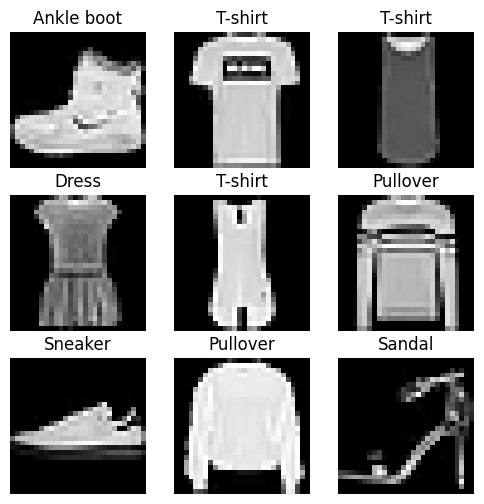

In [4]:
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Show samples
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

In [5]:
def create_model(filter_size, dropout_rate, num_layers, optimizer, lr):

    model = models.Sequential()

    # Input layer (fix warning also)
    model.add(tf.keras.Input(shape=(28,28,1)))

    # First Conv Layer
    model.add(layers.Conv2D(32, filter_size, activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(2,2))

    # Additional Conv Layers
    for _ in range(num_layers-1):
        model.add(layers.Conv2D(64, filter_size, activation='relu', padding='same'))
        model.add(layers.MaxPooling2D(2,2))

    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))

    # Optimizer selection
    if optimizer == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=lr)
    else:
        opt = tf.keras.optimizers.SGD(learning_rate=lr)


    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [6]:
# Hyperparameters
params = list(product(
    [0.001, 0.0001],        # lr
    ['adam','sgd'],         # optimizer
    [0.3, 0.5],             # dropout
    [(3,3),(5,5)],          # filter size
    [2,3]                   # layers
))


In [7]:
results = []

# Training loop
for lr, opt, dr, fs, nl in params:
    print(f"\nLR:{lr}, OPT:{opt}, DR:{dr}, FS:{fs}, Layers:{nl}")
    model = create_model(fs, dr, nl, opt, lr)
    model.fit(x_train, y_train, epochs=5, verbose=0)
    acc = model.evaluate(x_test, y_test, verbose=0)[1]
    print("Accuracy:", acc)
    results.append((acc, lr, opt, dr, fs, nl))

# Best config
best = max(results)
print("\nBEST:", best)


LR:0.001, OPT:adam, DR:0.3, FS:(3, 3), Layers:2
Accuracy: 0.9086999893188477

LR:0.001, OPT:adam, DR:0.3, FS:(3, 3), Layers:3
Accuracy: 0.9081000089645386

LR:0.001, OPT:adam, DR:0.3, FS:(5, 5), Layers:2
Accuracy: 0.9124000072479248

LR:0.001, OPT:adam, DR:0.3, FS:(5, 5), Layers:3
Accuracy: 0.9086999893188477

LR:0.001, OPT:adam, DR:0.5, FS:(3, 3), Layers:2
Accuracy: 0.9068999886512756

LR:0.001, OPT:adam, DR:0.5, FS:(3, 3), Layers:3
Accuracy: 0.9027000069618225

LR:0.001, OPT:adam, DR:0.5, FS:(5, 5), Layers:2
Accuracy: 0.907800018787384

LR:0.001, OPT:adam, DR:0.5, FS:(5, 5), Layers:3
Accuracy: 0.9078999757766724

LR:0.001, OPT:sgd, DR:0.3, FS:(3, 3), Layers:2
Accuracy: 0.7759000062942505

LR:0.001, OPT:sgd, DR:0.3, FS:(3, 3), Layers:3
Accuracy: 0.7516000270843506

LR:0.001, OPT:sgd, DR:0.3, FS:(5, 5), Layers:2
Accuracy: 0.7767000198364258

LR:0.001, OPT:sgd, DR:0.3, FS:(5, 5), Layers:3
Accuracy: 0.7723000049591064

LR:0.001, OPT:sgd, DR:0.5, FS:(3, 3), Layers:2
Accuracy: 0.767400026

In [11]:

# Final model
_, lr, opt, dr, fs, nl = best
final_model = create_model(fs, dr, nl, opt, lr)

history = final_model.fit(x_train, y_train, epochs=10,
                          validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.8262 - loss: 0.4911 - val_accuracy: 0.8808 - val_loss: 0.3275
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8859 - loss: 0.3210 - val_accuracy: 0.8932 - val_loss: 0.2850
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8989 - loss: 0.2789 - val_accuracy: 0.9065 - val_loss: 0.2597
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9112 - loss: 0.2483 - val_accuracy: 0.9131 - val_loss: 0.2477
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9148 - loss: 0.2275 - val_accuracy: 0.9090 - val_loss: 0.2587
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9236 - loss: 0.2060 - val_accuracy: 0.9037 - val_loss: 0.2770
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9285 - loss: 0.1927 - val_accuracy: 0.9118 - val_loss: 0.2474
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9332 - loss: 0.1767 

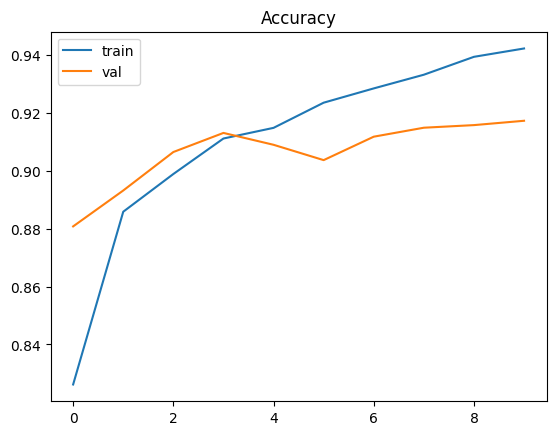

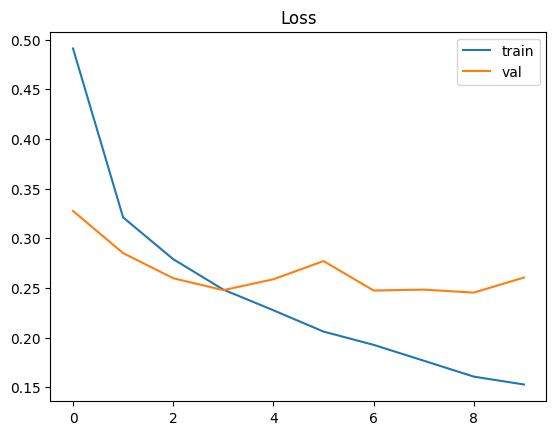

In [12]:
# Plots
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend(); plt.title("Accuracy"); plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend(); plt.title("Loss"); plt.show()


In [13]:



# Predictions
for i in range(5):
    pred = np.argmax(final_model.predict(x_test[i:i+1]))
    print("Pred:", class_names[pred], "| Actual:", class_names[y_test[i]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step
Pred: Ankle boot | Actual: Ankle boot
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Pred: Pullover | Actual: Pullover
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Pred: Trouser | Actual: Trouser
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Pred: Trouser | Actual: Trouser
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Pred: Shirt | Actual: Shirt
